In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns

In [2]:
df= pd.read_csv('Dataset\job_salary_prediction_dataset.csv')
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\j'
<>:1: SyntaxWarning: invalid escape sequence '\j'
C:\Users\HP\AppData\Local\Temp\ipykernel_5380\345956631.py:1: SyntaxWarning: invalid escape sequence '\j'
  df= pd.read_csv('Dataset\job_salary_prediction_dataset.csv')


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
df.shape

(250000, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [5]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [8]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


##  Analisis Strategis & Efisiensi

   1. Hitung rata-rata gaji per tahun pengalaman (salary / experience_years) untuk setiap education_level.Level mana yang memberikan nilai ekonomi tertinggi diawal karier (0-3 tahun)?
   2. Di industri mana kepemilikan certifications memberikan kenaikan persentase gaji paling signifikan dibandingkan dengan yang tidak memilikinya?
   3. Identifikasi job_title yang memiliki skills_count di atas rata-rata tetapi memiliki salary di bawah median industri. (Indikasi underpaid).
   4. Apakah probabilitas mendapatkan remote_work meningkat seiring bertambahnya experience_years? Tunjukkan perbandingannya dalam persentase.
   5. Setelah mengontrol variabel experience_years (misal: hanya ambil yang 5-10 tahun), lokasi mana yang memberikan gaji tertinggi untuk industry Teknologi?

## Statistik & Distribusi

   1. Temukan job_title yang memiliki varians (standar deviasi) gaji paling tinggi. Mengapa posisi ini memiliki rentang gaji yang sangat lebar?
   2. Hitung kekuatan korelasi antara skills_count, experience_years, dan certifications terhadap salary. Mana yang paling dominan?
   3. Apakah perusahaan besar (Large) cenderung mensyaratkan education_level yang lebih tinggi dibandingkan perusahaan kecil (Small) untuk posisi yang sama?
   4. Buatlah pengelompokan (binning) gaji menjadi (Low, Medium, High) dan analisis bagaimana distribusi skills_count di masing-masing kelompok tersebut.
   5. Di setiap location, tentukan industry apa yang paling mendominasi pasar tenaga kerja dan berapa rata-rata gaji di sana.

## Prediksi & Pola Karier

   1. Pada experience_years ke berapa biasanya terjadi lonjakan gaji terbesar (salary jump) secara rata-rata di seluruh industri?
   2. Apakah karyawan di kota-kota pusat bisnis memiliki skills_count yang lebih tinggi dibandingkan daerah lain untuk job_title yang identik?
   3. Bandingkan salary karyawan remote_work dengan on-site pada company_size yang sama. Apakah remote work cenderung dibayar lebih rendah atau lebih tinggi?
   4. Cari angka certifications optimal (titik jenuh) di mana penambahan sertifikasi setelah angka tersebut tidak lagi meningkatkan salary secara signifikan.
   5. Buatlah skor gabungan (Score = Experience * Skills * Certs) dan temukan 10 karyawan dengan skor tertinggi, lalu bandingkan apakah gaji mereka sudah sesuai dengan skor tersebut.

In [9]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


##  Analisis Strategis & Efisiensi

   1. Hitung rata-rata gaji per tahun pengalaman (salary / experience_years) untuk setiap education_level.Level mana yang memberikan nilai ekonomi tertinggi diawal karier (0-3 tahun)?
   2. Di industri mana kepemilikan certifications memberikan kenaikan persentase gaji paling signifikan dibandingkan dengan yang tidak memilikinya?
   3. Identifikasi job_title yang memiliki skills_count di atas rata-rata tetapi memiliki salary di bawah median industri. (Indikasi underpaid).
   4. Apakah probabilitas mendapatkan remote_work meningkat seiring bertambahnya experience_years? Tunjukkan perbandingannya dalam persentase.
   5. Setelah mengontrol variabel experience_years (misal: hanya ambil yang 5-10 tahun), lokasi mana yang memberikan gaji tertinggi untuk industry Teknologi?

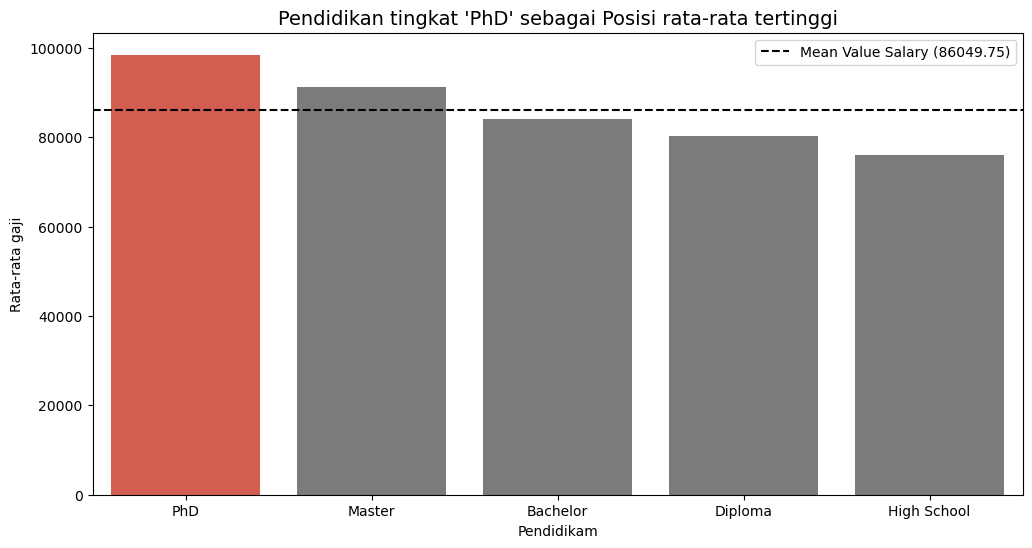

level pendidikan dengan rata-rata gaji tertinggi adalah PhD sebesar 98493.5


In [10]:
#soal nomor 1
experience_filtered = df[(df['experience_years'] >= 0) & (df['experience_years'] <= 3)]
df['mean_salary'] = (experience_filtered['salary']/ experience_filtered['experience_years'].replace(0,1))# 0th pengalaman diasumsikan jadi 1th
df_educat = df.groupby('education_level')[['mean_salary','salary']].mean().sort_values(by='mean_salary',ascending=False).round(2)

top_edu = df_educat['mean_salary'].idxmax()
top_value = df_educat['mean_salary'].max()

colors = ['#e74c3c' if (x == top_value ) else "#7b7b7b" for x in df_educat['mean_salary']]
meanValue = df_educat['mean_salary'].mean().round(2)
    
plt.figure(figsize=(12, 6))
sns.barplot(x=df_educat.index,y=df_educat['mean_salary'] ,palette=colors,hue=df_educat.index)
plt.axhline(meanValue, color='black', linestyle='--', label=f'Mean Value Salary ({meanValue})')
plt.title(f"Pendidikan tingkat '{top_edu}' sebagai Posisi rata-rata tertinggi", fontsize=14)
plt.xlabel('Pendidikam')
plt.ylabel('Rata-rata gaji')
plt.legend()
plt.show()
print(f"level pendidikan dengan rata-rata gaji tertinggi adalah {top_edu} sebesar {top_value}")

In [11]:
# df.head(2)

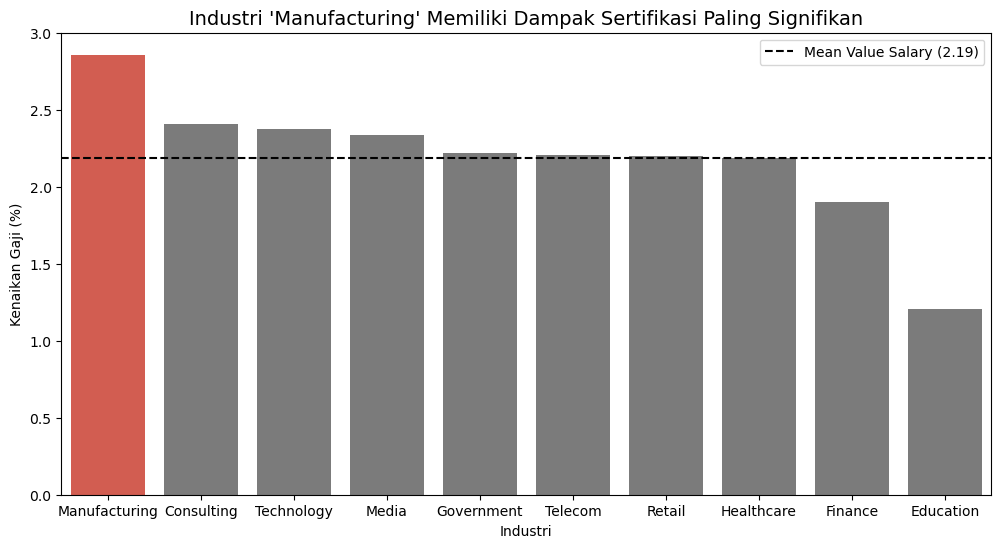

Industri dengan kenaikan persentase gaji tertinggi adalah Manufacturing sebesar 2.86%


In [12]:
#soal nomor 2
#2. Di industri mana kepemilikan certifications memberikan kenaikan persentase gaji paling signifikan dibandingkan dengan yang tidak memilikinya?
df_certif_filtered = df[df['certifications']>0]
df_noncertif_filtered = df[df['certifications'] == 1]

mean_salary_certif =df_certif_filtered.groupby('industry')['salary'].mean()
mean_salart_noncertif = df_noncertif_filtered.groupby('industry')['salary'].mean()

calcul_industry = (((mean_salary_certif-mean_salart_noncertif)/mean_salart_noncertif) * 100).sort_values(ascending=False)

top_industry = calcul_industry.idxmax()
value_industry = calcul_industry.max()
mean_value_global = calcul_industry.mean().round(2)

colors = ['#e74c3c' if (x == top_industry) else "#7b7b7b" for x in calcul_industry.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=calcul_industry.index, y=calcul_industry.round(2), palette=colors,  hue=calcul_industry.index)
plt.axhline(mean_value_global, color='black', linestyle='--', label=f'Mean Value Salary ({mean_value_global})')
plt.title(f"Industri '{top_industry}' Memiliki Dampak Sertifikasi Paling Signifikan", fontsize=14)
plt.xlabel('Industri')
plt.ylabel('Kenaikan Gaji (%)')
plt.legend()
plt.show()
print(f"Industri dengan kenaikan persentase gaji tertinggi adalah {top_industry} sebesar {value_industry:.2f}%")

In [13]:
# soal nomor 3
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,mean_salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,NaN
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,NaN


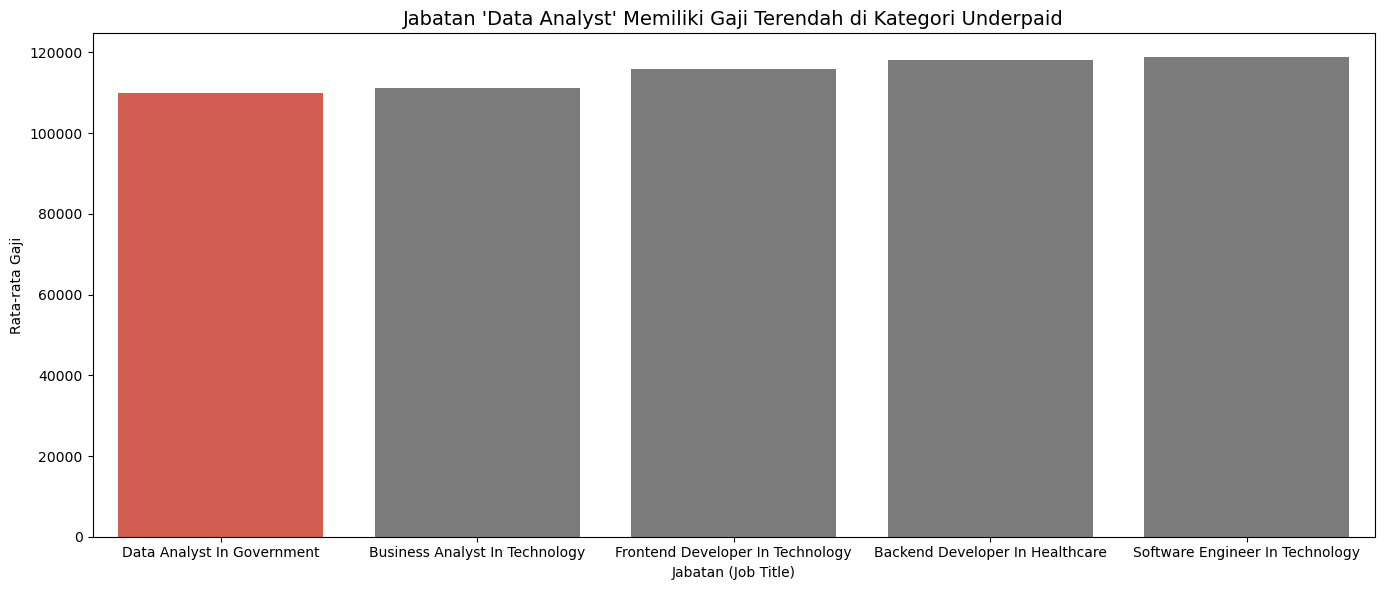

Jabatan underpaid dengan gaji terendah adalah Data Analyst In Government dengan gaji sebesar 110016.68


In [14]:
# 3. Identifikasi job_title yang memiliki skills_count di atas rata-rata tetapi memiliki salary di bawah median industri. (Indikasi underpaid).
data= df[['job_title','industry','salary','skills_count']]
avg_skill = data.groupby('job_title')['skills_count'].mean()
med_salary = data.groupby('industry')['salary'].median()
job_underpaid = data[(data['skills_count'] > data['job_title'].map(avg_skill)) & (data['salary'] < data['industry'].map(med_salary))].sort_values(by='salary',ascending=True)

topjob_underpaid = job_underpaid[['job_title', 'salary']].iloc[0]
plot_data = job_underpaid.groupby('job_title')['salary'].mean().sort_values(ascending=True).head(5)
industry_map = job_underpaid.drop_duplicates('job_title').set_index('job_title')['industry']
plot_data.index = [f"{job} In {industry_map.get(job)}" for job in plot_data.index]

global_mean_salary = plot_data.mean()
colors = ['#e74c3c' if (x == plot_data.min()) else "#7b7b7b" for x in plot_data]

plt.figure(figsize=(14, 6))
sns.barplot(x=plot_data.index, y=plot_data.values, palette=colors,hue=plot_data.index,legend=False)
plt.title(f"Jabatan '{topjob_underpaid['job_title']}' Memiliki Gaji Terendah di Kategori Underpaid", fontsize=14)
plt.xlabel('Jabatan (Job Title)')
plt.ylabel('Rata-rata Gaji')
plt.tight_layout() # Memastikan tidak ada teks yang terpotong
plt.show()
print(f"Jabatan underpaid dengan gaji terendah adalah {plot_data.index[0]} dengan gaji sebesar {plot_data.iloc[0]:.2f}")

In [15]:
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,mean_salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,NaN
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,NaN


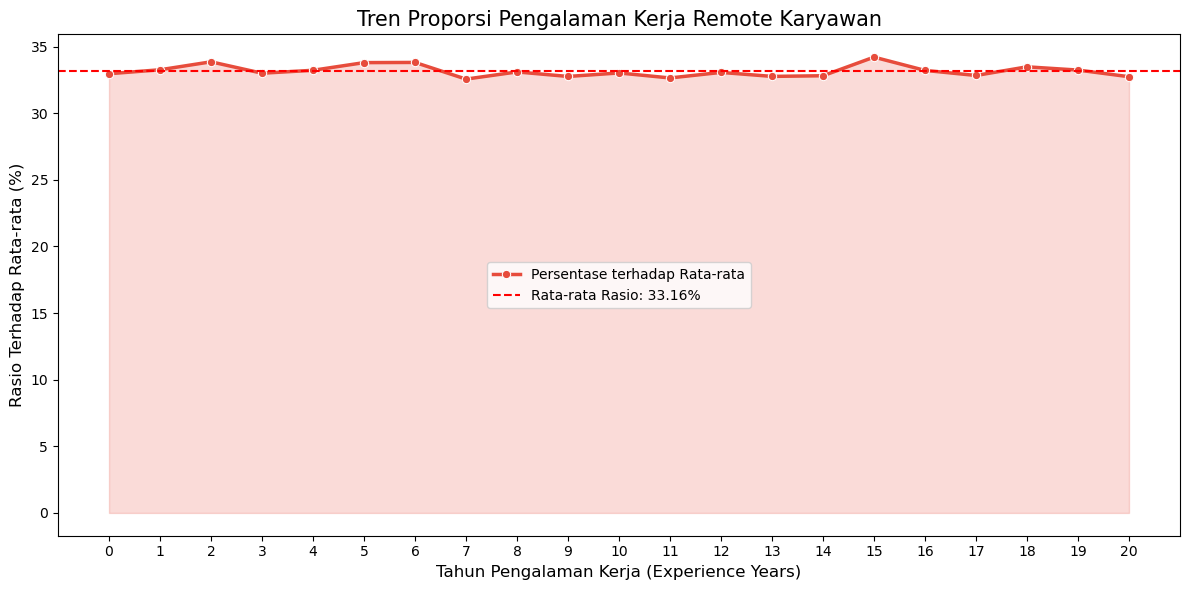

In [16]:
# soal nomor 4
# 4. Apakah probabilitas mendapatkan remote_work meningkat seiring bertambahnya experience_years? Tunjukkan perbandingannya dalam persentase.
data = df[['experience_years','remote_work']]
data_filtered = data[data['remote_work'] == 'Yes'].sort_values(by='experience_years',ascending=True)
total_perYear = data['experience_years'].value_counts()
yes_perYear = data_filtered['experience_years'].value_counts()

plot_data = (yes_perYear/total_perYear * 100).fillna(0).sort_index()
mean_line_val = plot_data.mean()
max_val = plot_data.max()
max_exp = plot_data.idxmax()

plt.figure(figsize=(12, 6))
sns.lineplot(x=plot_data.index, y=plot_data.values, marker='o', color='#e74c3c', linewidth=2.5, label='Persentase terhadap Rata-rata')
plt.fill_between(plot_data.index, plot_data.values, alpha=0.2, color='#e74c3c')
plt.axhline(mean_line_val, color='red', linestyle='--', label=f'Rata-rata Rasio: {mean_line_val:.2f}%')
plt.title('Tren Proporsi Pengalaman Kerja Remote Karyawan', fontsize=15)
plt.xlabel('Tahun Pengalaman Kerja (Experience Years)', fontsize=12)
plt.ylabel('Rasio Terhadap Rata-rata (%)', fontsize=12)
plt.xticks(plot_data.index) 
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,mean_salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,NaN
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,NaN


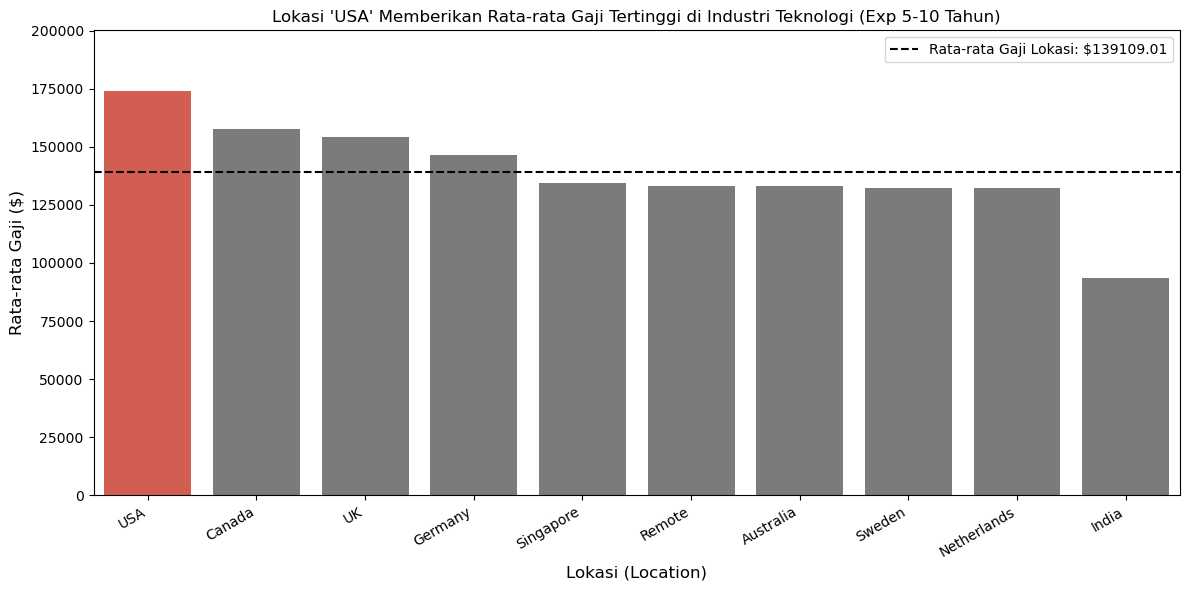

Lokasi yang memberikan gaji tertinggi dibidang Teknologi adalah : USA sebesar $174,052.38


In [22]:
#soal nomor 5
# 5. Setelah mengontrol variabel experience_years (misal: hanya ambil yang 5-10 tahun), lokasi mana yang memberikan gaji tertinggi untuk industry Teknologi?
data = df[['experience_years','location','industry','salary']].copy()
data_filtered = data[(data['industry']=='Technology') & (data['experience_years'] >= 5) & (data['experience_years'] <= 10)]
data_location = data_filtered.groupby('location')['salary'].mean().sort_values(ascending=False).round(2)

max_location = data_location.idxmax()
max_salary = data_location.max()

location_mean_salary = data_location.mean()
colors = ['#e74c3c' if (x == max_location) else "#7b7b7b" for x in data_location.index]


plt.figure(figsize=(12, 6))
sns.barplot(x=data_location.index,  y=data_location.values,  palette=colors,  hue=data_location.index,  legend=False)
plt.axhline(location_mean_salary, color='black', linestyle='--', label=f'Rata-rata Gaji Lokasi: ${location_mean_salary:.2f}')
plt.title(f"Lokasi '{max_location}' Memberikan Rata-rata Gaji Tertinggi di Industri Teknologi (Exp 5-10 Tahun)")
plt.xlabel('Lokasi (Location)', fontsize=12)
plt.ylabel('Rata-rata Gaji ($)', fontsize=12)
plt.ylim(0, max_salary * 1.15) # Memberikan ruang di atas batang tertinggi untuk teks label
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Lokasi yang memberikan gaji tertinggi dibidang Teknologi adalah : {max_location} sebesar ${max_salary:,.2f}")
